In [1]:
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
import matplotlib.pyplot as plt

In [2]:
# nltk.download()

In [3]:
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')
# '''
# When to download them?
# Once per environment
# Required when: Setting up NLP pipelines and 
#                 Running NLTK code on a new machine or server
#                 Using Jupyter/Colab for the first time

# These lines download NLTK data resources that are not bundled with 
# the NLTK library by default but are required for common Natural Language 
# Processing (NLP) tasks
# 'punkt'--- Provides pre-trained tokenizers for sentence and word segmentation.
#            Splits raw text into sentences and words
#             Uses linguistic rules (not just spaces or punctuation)
# 'stopwords'--- Contains lists of stop words for multiple languages.
#             Stop words are common words that usually do not add meaning 
#             in text analysis.
#             Examples of stop words:English: the, is, in, on, at, and, but
#             Used in: Text preprocessing, Information retrieval, Machine learning pipelines
# 'wordnet'---Provides the WordNet lexical database.
#             Used for:Lemmatization, Synonym and antonym lookup, Semantic similarity
#             WordNet includes: Words grouped into synsets (sets of synonyms)
#             Relationships like: Hypernyms (is-a) and Hyponyms (subclasses)
# 'omw-1.4'--- Stands for Open Multilingual WordNet
#             Required by WordNet for multilingual support
#             Enables WordNet to work correctly with non-English languages and 
#             Needed for newer WordNet versions to function without errors

# '''

# #additional 
# nltk.download('punkt_tab')
# ''' 
# punkt_tab contains language-specific statistical tables used by the Punkt 
# tokenizer.
# These tables store:Abbreviation probabilities, Sentence boundary statistics, 
# Orthographic heuristics

# Why is it separate from punkt?
# Newer NLTK versions split Punkt data into:
# punkt → tokenizer code & models
# punkt_tab → precomputed parameter tables

# This separation: Reduces load time, 
#                 Improves tokenizer accuracy
#                 Supports easier updates for multiple languages

# When is punkt_tab actually needed?
#     It is required when you use sentence tokenization

# Without punkt_tab, you may see errors like:
# LookupError: Resource punkt_tab not found

# What problem does it solve?
#     Without punkt_tab, Punkt:Cannot correctly identify:
#                             Abbreviations (Dr., Mr.)
#                             Sentence boundaries
#                             Periods used in numbers or initials
#                             Fails or produces incorrect sentence splits'''

In [4]:
data = open("./assets/AgathaChristieDeathOnTheNile.txt",'r').read()

sentences = sent_tokenize(data)
words = word_tokenize(data)

In [5]:
len(data)

439809

In [6]:
# punctuation 
words = [word.lower() for word in words if word.isalpha()]

In [7]:
# remove stopwords 
stop_words = set(stopwords.words('english'))
filtered_words = [word for word in words if word not in stop_words]

In [8]:
len(stop_words)

198

In [9]:
stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in filtered_words]

In [10]:
lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in filtered_words]
processed_text = ' '.join(lemmatized_words)

In [11]:
len(processed_text)

253140

In [12]:
words = nltk.word_tokenize(processed_text)
word_freq = nltk.FreqDist(words)
top_words = word_freq.most_common(40)

In [13]:
top_words

[('said', 738),
 ('poirot', 615),
 ('one', 384),
 ('linnet', 306),
 ('doyle', 304),
 ('yes', 263),
 ('race', 255),
 ('miss', 254),
 ('simon', 248),
 ('would', 232),
 ('know', 231),
 ('think', 228),
 ('like', 183),
 ('man', 180),
 ('cabin', 175),
 ('see', 174),
 ('say', 172),
 ('got', 171),
 ('looked', 169),
 ('went', 169),
 ('little', 167),
 ('thing', 159),
 ('head', 157),
 ('allerton', 150),
 ('jacqueline', 149),
 ('could', 147),
 ('cornelia', 147),
 ('tim', 144),
 ('well', 143),
 ('pennington', 141),
 ('two', 139),
 ('go', 137),
 ('quite', 132),
 ('came', 125),
 ('time', 124),
 ('girl', 121),
 ('come', 116),
 ('face', 115),
 ('de', 114),
 ('fanthorp', 113)]

In [14]:
from wordcloud import WordCloud,STOPWORDS
from PIL import Image
import numpy as np 

(np.float64(-0.5), np.float64(999.5), np.float64(499.5), np.float64(-0.5))

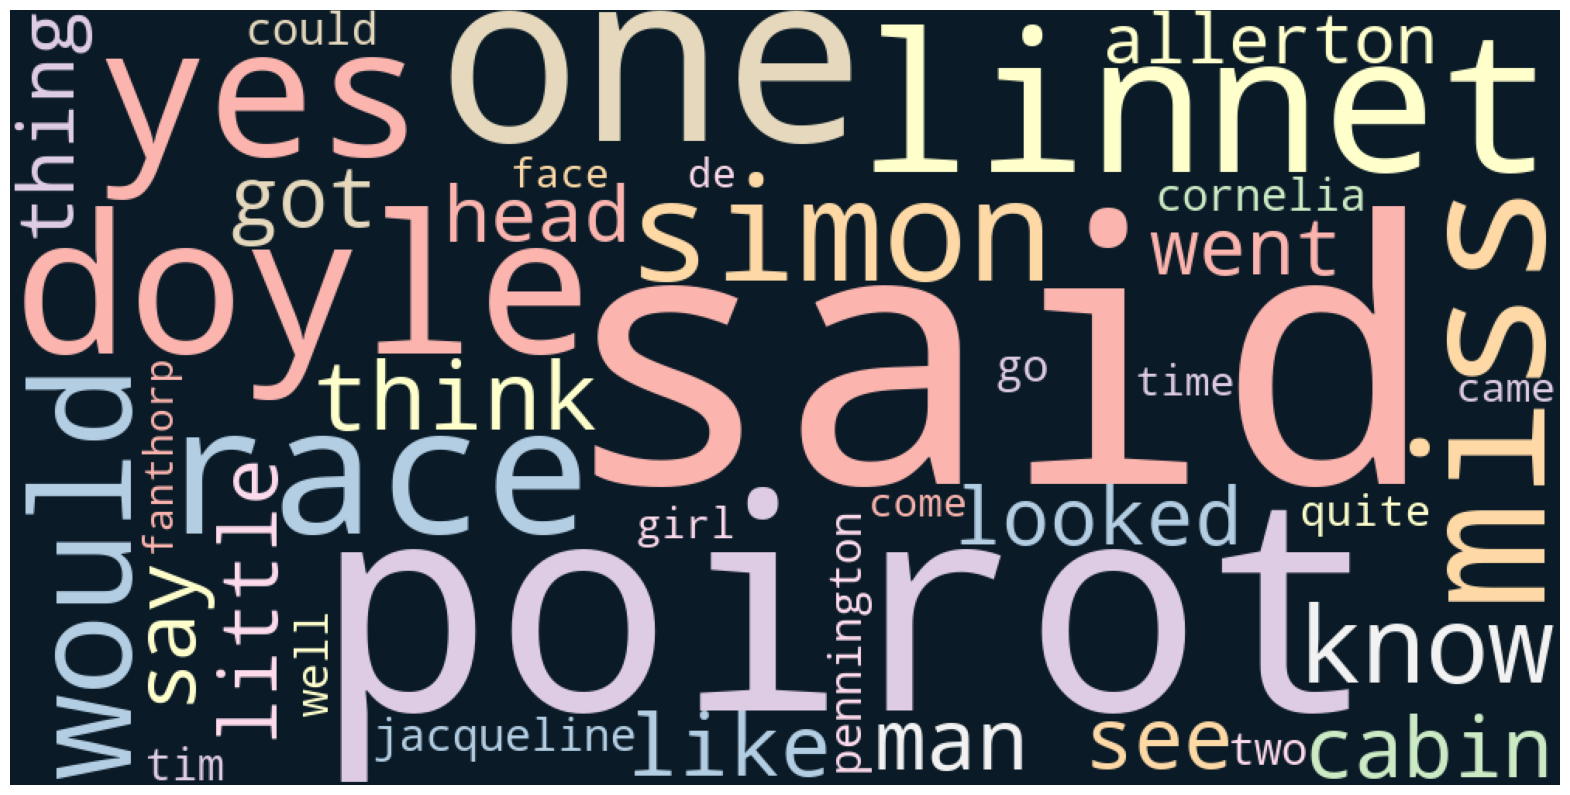

In [15]:
wordcloud = WordCloud(width=1000,height=500,random_state=1,background_color='#0A1B27',colormap='Pastel1',
                     collocations=False,stopwords=STOPWORDS).generate_from_frequencies(dict(top_words))
''' Collocations are pairs of words that commonly appear together in text 
and carry a specific meaning.
Examples: machine learning, artificial intelligence, data science, New York
collocations=True (default) 
    The word cloud may include:Bigram phrases (two-word combinations)
collocations=False
    Only individual words are shown
'''
plt.figure(figsize=(20,15))
plt.imshow(wordcloud)
plt.axis("off")

In [16]:
car_mask = np.array(Image.open("./assets/cloud2.jpeg"))
car_mask = 255 - car_mask
''' 
These two lines are used to load an image and convert it into a mask 
that controls where words are drawn in a WordCloud.
Image.open(...)
→ Opens the image file using PIL (Python Imaging Library)

np.array(...)
→ Converts the image into a NumPy array of pixel values

Result:
car_mask becomes a 2D or 3D array (depending on image type)
Each element represents a pixel intensity
    Grayscale: 0–255
    RGB: [R, G, B]

This array is used as a mask shape for the WordCloud.'''

' \nThese two lines are used to load an image and convert it into a mask \nthat controls where words are drawn in a WordCloud.\nImage.open(...)\n→ Opens the image file using PIL (Python Imaging Library)\n\nnp.array(...)\n→ Converts the image into a NumPy array of pixel values\n\nResult:\ncar_mask becomes a 2D or 3D array (depending on image type)\nEach element represents a pixel intensity\n    Grayscale: 0–255\n    RGB: [R, G, B]\n\nThis array is used as a mask shape for the WordCloud.'

(np.float64(-0.5), np.float64(318.5), np.float64(157.5), np.float64(-0.5))

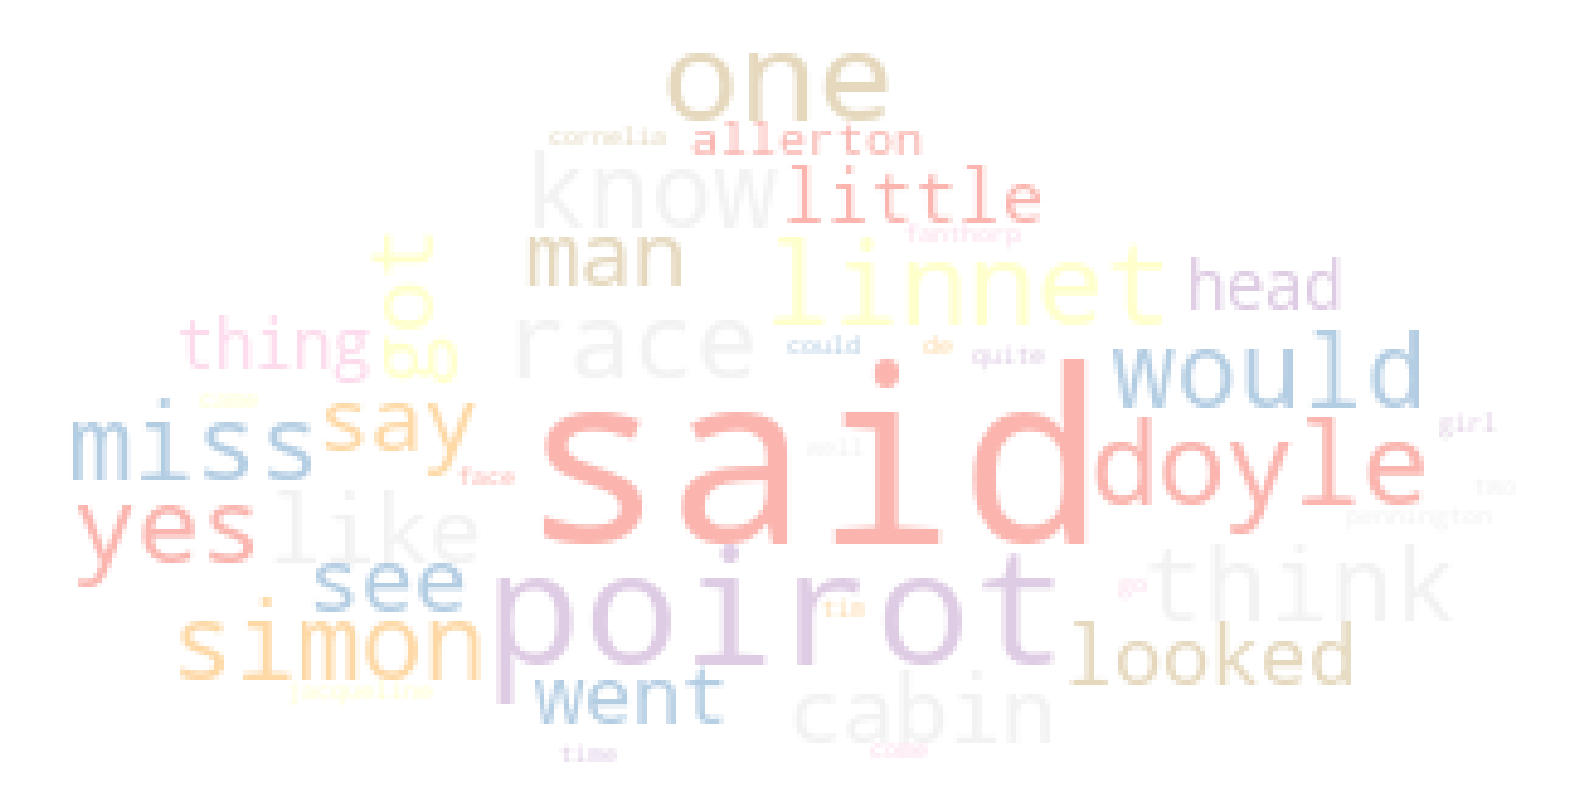

In [17]:
imgggg = WordCloud(width=1000,height=500,random_state=1,mask=car_mask,colormap='Pastel1',
                     collocations=False,stopwords=STOPWORDS,  background_color='rgba(0, 0, 0, 0)',  # Transparent background
    mode='RGBA' ).generate_from_frequencies(dict(top_words))

plt.figure(figsize=(20,15))
plt.imshow(imgggg)
plt.axis("off")